<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/PREDIKSI_BEBAN_LISTRIK_PER_JAM_DENGAN_MULTILAYER_PERCEPTRON_(MLP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PREDIKSI BEBAN LISTRIK PER JAM DENGAN MULTILAYER PERCEPTRON (MLP)
Alur program: load data -> validasi -> feature engineering -> training ->
evaluasi -> simpan model -> uji development sederhana

File lokal tidak ditemukan. Mengunduh arsip dataset resmi dari UCI...
Unduhan dan ekstraksi berhasil. File Excel: /content/pgcb_project/PGCB_date_power_demand.xlsx

Ukuran data awal: (92650, 15)
Daftar kolom:
['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal', 'remarks']

Contoh 5 baris awal:


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN



Kolom target terpilih : demand_mw
Sumber kolom waktu    : datetime

Ukuran data setelah pembersihan awal: (92650, 16)
Ukuran data setelah feature engineering: (418, 35)
Jumlah fitur akhir: 33


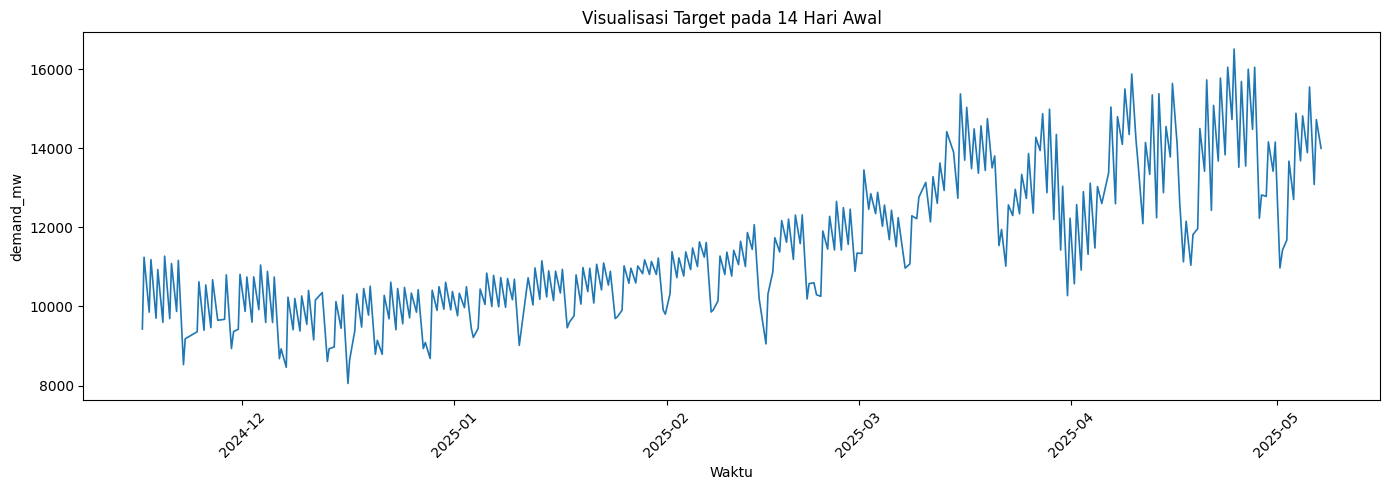

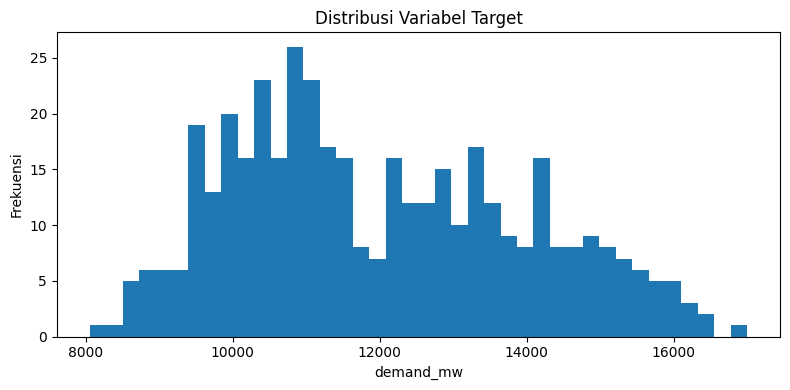


Ringkasan statistik target:


,Statistik,Nilai
0,count,418.000000
1,mean,11980.444976
2,std,1973.514786
3,min,8054.000000
4,25%,10407.250000
5,50%,11527.000000
6,75%,13477.250000
7,90%,14836.800000
8,max,17000.000000



Ukuran train: (292, 33) (292,)
Ukuran val  : (63, 33) (63,)
Ukuran test : (63, 33) (63,)

Distribusi bobot sampel:


,Kelompok,Bobot,Jumlah Observasi
0,Normal,1.0,219
1,Menengah-Tinggi (>=Q75),1.3,43
2,Puncak (>=Q90),2.0,30



Ringkasan arsitektur model:


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,617 (61.00 KB)

 Trainable params: 15,169 (59.25 KB)

 Non-trainable params: 448 (1.75 KB)


Memulai pelatihan awal...
Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - loss: 2.5916 - mae: 1.2691 - mse: 2.2299 - val_loss: 1.5407 - val_mae: 0.9642 - val_mse: 1.3620 - learning_rate: 0.0010
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 2.5074 - mae: 1.1853 - mse: 2.1410 - val_loss: 1.3516 - val_mae: 0.8953 - val_mse: 1.1730 - learning_rate: 0.0010
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 2.2798 - mae: 1.1637 - mse: 1.8864 - val_loss: 1.2076 - val_mae: 0.8406 - val_mse: 1.0291 - learning_rate: 0.0010
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 2.3494 - mae: 1.1539 - mse: 1.9460 - val_loss: 1.0918 - val_mae: 0.7954 - val_mse: 0.9133 - learning_rate: 0.0010
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 2.2273 - mae: 1.1263 - mse: 1.7622 - val_loss: 1.0528 - val_mae: 0.7842 - val_mse: 0.8744 - learning_rate: 0.0010
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 2.0996 - mae: 1.0918 - mse: 1.6813 - val_loss: 1.0451 - v

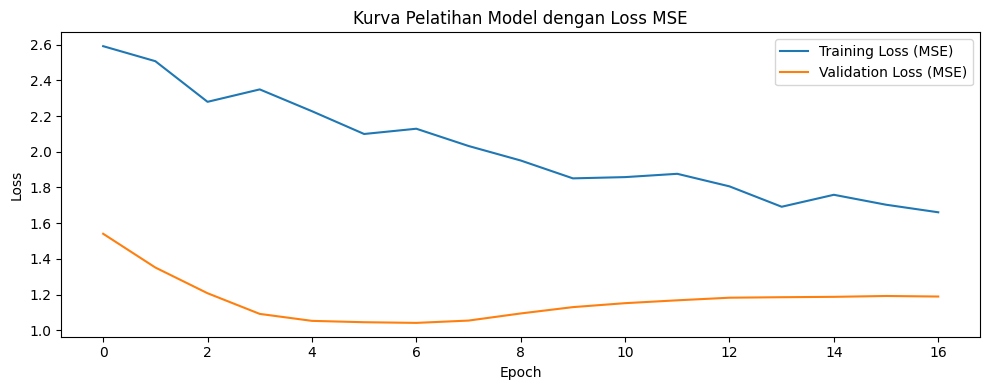


Hasil evaluasi data uji:


,Model,MAE,RMSE,MAPE (%),R2
0,Baseline Lag-24,857.285714,1253.142912,6.749990,0.301829
1,MLP (MSE + Reg lebih kuat),1074.777100,1331.681409,7.875887,0.211573


Evaluasi pada jam beban tinggi:


,Model,MAE,RMSE,MAPE (%),R2
0,MLP - Peak Hours,2268.490723,2338.289439,14.477614,-43.678005


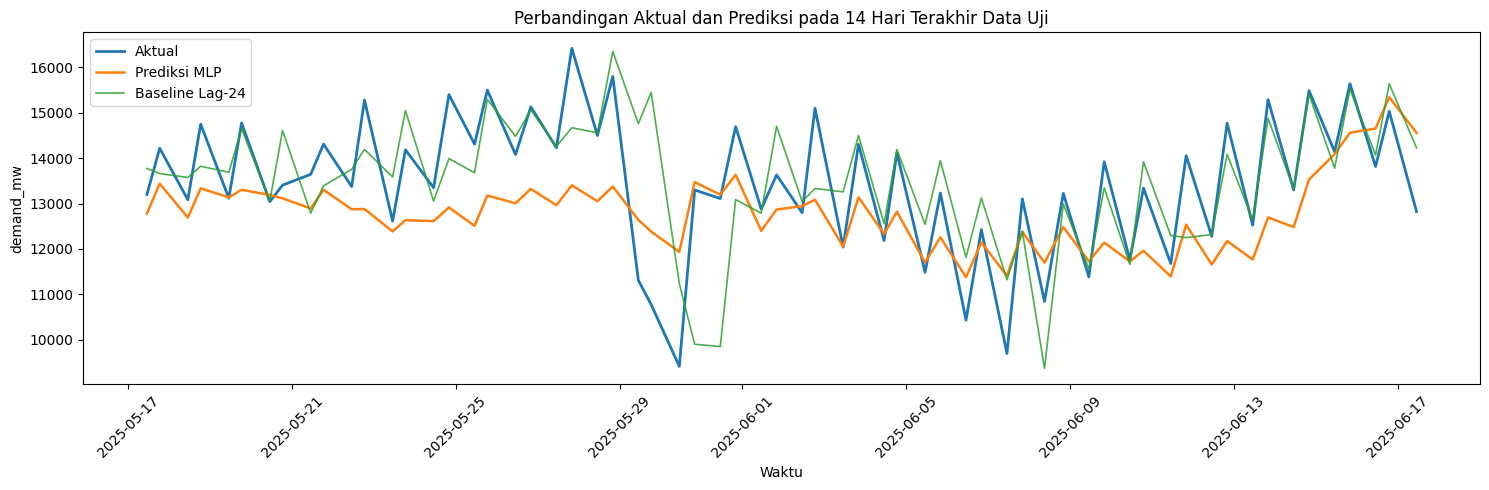

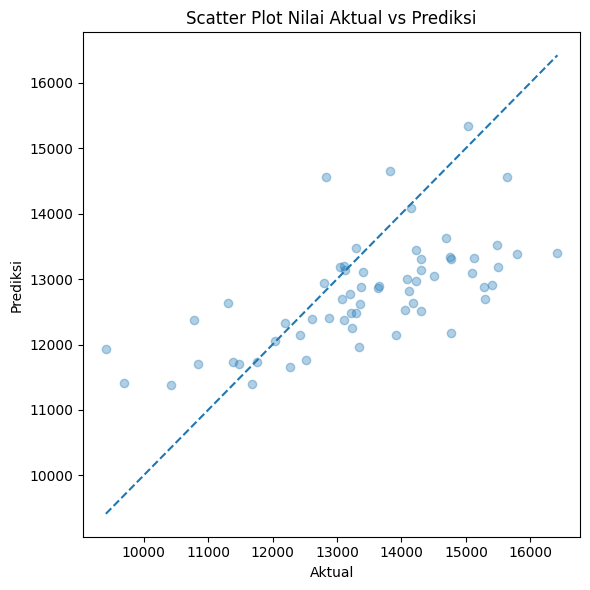

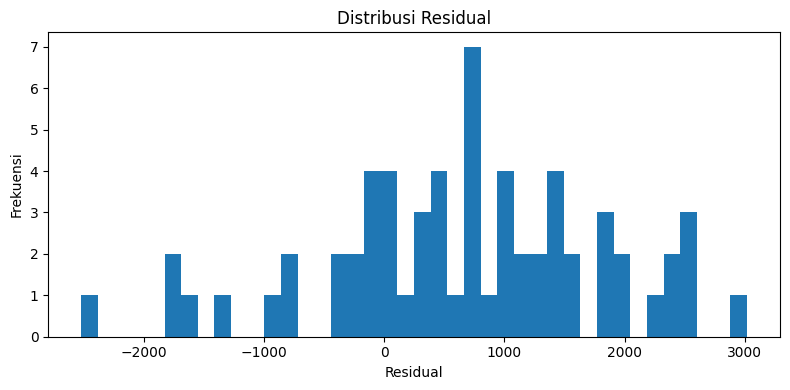


Model dan artefak berhasil disimpan.
Model  : /content/pgcb_project/artifacts/pgcb_mlp_model_improved.keras
Bundle : /content/pgcb_project/artifacts/preprocessing_bundle_improved.pkl
Meta   : /content/pgcb_project/artifacts/metadata_improved.json

TAHAP DEVELOPMENT - PENGUJIAN SEDERHANA

[UJI 1] Muat ulang model dan cek konsistensi prediksi
Status Uji 1: BERHASIL


,Prediksi Model Asli,Prediksi Model Muat Ulang,Selisih Absolut
0,12779.900391,12779.900391,0.0
1,13439.782227,13439.782227,0.0
2,12692.603516,12692.603516,0.0
3,13334.817383,13334.817383,0.0
4,13139.250977,13139.250977,0.0



[UJI 2] Inferensi sederhana pada 1 dan 3 data
Status Uji 2: BERHASIL


,Waktu,Aktual,Prediksi,Galat Absolut
0,2025-05-17 11:00:00,13200,12779.900391,420.099609
1,2025-05-17 18:30:00,14219,13439.782227,779.217773
2,2025-05-18 11:00:00,13085,12692.602539,392.397461



[UJI 3] Perbandingan terhadap baseline Lag-24
RMSE Baseline : 1253.1429
RMSE MLP      : 1331.6814
Status Uji 3  : BELUM BERHASIL

Ringkasan hasil pengujian development:


,Pengujian,Status
0,Uji 1 - Muat ulang model dan prediksi konsisten,BERHASIL
1,Uji 2 - Inferensi 1 dan 3 data menghasilkan ni...,BERHASIL
2,Uji 3 - RMSE model lebih baik dari baseline La...,BELUM BERHASIL



KESIMPULAN OTOMATIS
File dataset yang dipakai  : /content/pgcb_project/PGCB_date_power_demand.xlsx
Target prediksi            : demand_mw
Jumlah fitur akhir         : 33
Model tersimpan            : /content/pgcb_project/artifacts/pgcb_mlp_model_improved.keras
Artefak praproses          : /content/pgcb_project/artifacts/preprocessing_bundle_improved.pkl
RMSE Baseline              : 1253.1429
RMSE MLP                   : 1331.6814
Kesimpulan: model berhasil dilatih, disimpan, dan diuji ulang, tetapi performa relatif terhadap baseline masih perlu ditingkatkan.


In [1]:
# ================================================================
# JUDUL PROGRAM
# PREDIKSI BEBAN LISTRIK PER JAM DENGAN MULTILAYER PERCEPTRON (MLP)
# PADA PGCB HOURLY GENERATION DATASET (BANGLADESH)
#
# DESKRIPSI SINGKAT
# Program ini dirancang untuk:
# 1) memuat dataset PGCB secara aman tanpa bergantung pada fetch_ucirepo,
# 2) melakukan praproses dan rekayasa fitur secara logis,
# 3) melatih model Multilayer Perceptron (MLP) untuk regresi,
# 4) menyimpan model dan artefak praproses,
# 5) menjalankan pengujian development sederhana untuk menilai
#    keberhasilan awal model yang dikembangkan.
#
# CATATAN METODOLOGIS
# - Target diarahkan ke variabel demand/load yang paling relevan
#   untuk prediksi beban listrik.
# - Pembagian data dilakukan secara kronologis karena data bersifat time series.
# - Fitur historis dibentuk hanya dari masa lalu untuk mencegah data leakage.
# - Strategi regularisasi digunakan untuk menekan overfitting.
#
# REKOMENDASI PERBAIKAN (Berdasarkan evaluasi awal):
# 1. Gunakan fungsi loss Mean Squared Error (MSE) yang lebih sensitif terhadap error besar,
#    karena model saat ini (Huber) kurang optimal dalam menangani nilai ekstrem (peak hours).
# 2. Tingkatkan regularisasi L2 pada layer dense untuk mengurangi overfitting mengingat jumlah data terbatas (418 sampel).
# 3. Lakukan hyperparameter tuning sederhana pada jumlah neuron dan learning rate untuk meningkatkan performa.
# ================================================================

# -----------------------------
# Instalasi pustaka (jika perlu)
# -----------------------------
!pip -q install openpyxl scikit-learn tensorflow requests

# -----------------------------
# Import pustaka
# -----------------------------
import os
import io
import re
import json
import glob
import pickle
import zipfile
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras import layers, regularizers, callbacks, models
from IPython.display import display

# -----------------------------
# Reprodusibilitas
# -----------------------------
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("=" * 100)
print("PREDIKSI BEBAN LISTRIK PER JAM DENGAN MULTILAYER PERCEPTRON (MLP)")
print("=" * 100)
print("Alur program: load data -> validasi -> feature engineering -> training ->")
print("evaluasi -> simpan model -> uji development sederhana\n")

# -----------------------------
# Konfigurasi dasar
# -----------------------------
WORKDIR = Path("/content/pgcb_project")
WORKDIR.mkdir(parents=True, exist_ok=True)

UCI_ZIP_URL = "https://archive.ics.uci.edu/static/public/1175/pgcb%2Bhourly%2Bgeneration%2Bdataset%2B%28bangladesh%29.zip"

# -----------------------------
# Fungsi bantu
# -----------------------------
def pilih_kolom(columns, kata_kunci, exclude_keywords=None):
    """Memilih nama kolom secara fleksibel berdasarkan kata kunci."""
    if exclude_keywords is None:
        exclude_keywords = []

    cols = list(columns)
    cols_norm = {
        c: re.sub(r"[^a-z0-9]+", "_", str(c).strip().lower())
        for c in cols
    }

    for kata in kata_kunci:
        kata = kata.lower()
        for c in cols:
            text = cols_norm[c]
            if kata in text and not any(ex in text for ex in exclude_keywords):
                return c
    return None

def safe_mape(y_true, y_pred):
    """Menghitung MAPE secara aman terhadap kemungkinan pembagi nol."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denom = np.clip(np.abs(y_true), 1e-8, None)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

def evaluasi_regresi(y_true, y_pred, nama_model="Model"):
    """Menyusun ringkasan metrik evaluasi regresi."""
    return pd.DataFrame({
        "Model": [nama_model],
        "MAE": [mean_absolute_error(y_true, y_pred)],
        "RMSE": [np.sqrt(mean_squared_error(y_true, y_pred))],
        "MAPE (%)": [safe_mape(y_true, y_pred)],
        "R2": [r2_score(y_true, y_pred)]
    })

def cek_finite(array_like, nama="array"):
    """Memastikan seluruh nilai numerik valid."""
    arr = np.asarray(array_like, dtype=float)
    if not np.all(np.isfinite(arr)):
        raise ValueError(f"Terdapat nilai non-finite pada {nama}.")
    return True

def ekstrak_xlsx_dari_zip(zip_path, extract_dir):
    """Mengekstrak file Excel pertama dari arsip ZIP."""
    with zipfile.ZipFile(zip_path, "r") as zf:
        members = [m for m in zf.namelist() if m.lower().endswith(".xlsx")]
        if not members:
            raise FileNotFoundError("Arsip ZIP tidak mengandung file .xlsx.")
        anggota = members[0]
        zf.extract(anggota, path=extract_dir)
        return Path(extract_dir) / anggota

def temukan_atau_unduh_dataset():
    """Strategi pemuatan data: cek lokal, ekstrak ZIP, atau unduh dari UCI."""
    kandidat = []
    pola_pencarian = [
        "/content/PGCB_date_power_demand.xlsx",
        "/content/*PGCB*power*demand*.xlsx",
        "/content/*pgcb*.xlsx",
        "/content/*PGCB*.zip",
        "/content/*pgcb*.zip",
        str(WORKDIR / "PGCB_date_power_demand.xlsx"),
        str(WORKDIR / "*PGCB*power*demand*.xlsx"),
        str(WORKDIR / "*pgcb*.xlsx"),
        str(WORKDIR / "*PGCB*.zip"),
        str(WORKDIR / "*pgcb*.zip"),
    ]

    for pola in pola_pencarian:
        kandidat.extend(glob.glob(pola))

    kandidat = sorted(set(kandidat))

    if kandidat:
        path_terpilih = Path(kandidat[0])
        print(f"File dataset ditemukan secara lokal: {path_terpilih}")
        if path_terpilih.suffix.lower() == ".xlsx":
            return path_terpilih
        elif path_terpilih.suffix.lower() == ".zip":
            xlsx_path = ekstrak_xlsx_dari_zip(path_terpilih, WORKDIR)
            print(f"File ZIP berhasil diekstrak ke: {xlsx_path}")
            return xlsx_path

    # Jika file lokal belum ada, unduh dari UCI
    print("File lokal tidak ditemukan. Mengunduh arsip dataset resmi dari UCI...")
    zip_path = WORKDIR / "pgcb_dataset.zip"

    try:
        response = requests.get(UCI_ZIP_URL, timeout=120)
        response.raise_for_status()
        with open(zip_path, "wb") as f:
            f.write(response.content)
    except Exception as e:
        raise RuntimeError(
            "Gagal mengunduh dataset resmi dari UCI. "
            "Silakan unggah file PGCB_date_power_demand.xlsx ke folder /content "
            "lalu jalankan ulang program."
        ) from e

    xlsx_path = ekstrak_xlsx_dari_zip(zip_path, WORKDIR)
    print(f"Unduhan dan ekstraksi berhasil. File Excel: {xlsx_path}")
    return xlsx_path

def bangun_datetime(df):
    """Membangun kolom datetime secara defensif."""
    cols = df.columns.tolist()

    # Opsi 1: kolom datetime langsung
    dt_col = pilih_kolom(cols, ["datetime", "timestamp", "date_time"])
    if dt_col is not None:
        dt = pd.to_datetime(df[dt_col], errors="coerce")
        if dt.notna().sum() > 0:
            return dt, dt_col

    # Opsi 2: kombinasi date + time
    date_col = pilih_kolom(cols, ["date"])
    time_only_col = pilih_kolom(cols, ["time"], exclude_keywords=["date"])
    if date_col is not None and time_only_col is not None and date_col != time_only_col:
        dt = pd.to_datetime(
            df[date_col].astype(str) + " " + df[time_only_col].astype(str),
            errors="coerce"
        )
        if dt.notna().sum() > 0:
            return dt, f"{date_col}+{time_only_col}"

    # Opsi 3: kombinasi date + hour
    hour_col = pilih_kolom(cols, ["hour", "hr"])
    if date_col is not None and hour_col is not None and date_col != hour_col:
        base_date = pd.to_datetime(df[date_col], errors="coerce")
        hour_num = pd.to_numeric(df[hour_col], errors="coerce")

        # Jika jam tampak 1-24, ubah menjadi 0-23
        if hour_num.dropna().between(1, 24).all():
            hour_num = hour_num - 1

        dt = base_date + pd.to_timedelta(hour_num.fillna(0), unit="h")
        if dt.notna().sum() > 0:
            return dt, f"{date_col}+{hour_col}"

    # Opsi 4: fallback
    synthetic = pd.date_range(start="2000-01-01", periods=len(df), freq="H")
    return pd.Series(synthetic, index=df.index), "synthetic_time"

# -----------------------------
# Memuat dataset
# -----------------------------
xlsx_path = temukan_atau_unduh_dataset()
df = pd.read_excel(xlsx_path, engine="openpyxl")

if df.empty:
    raise ValueError("Dataset berhasil dimuat, tetapi isi tabel kosong.")

print("\nUkuran data awal:", df.shape)
print("Daftar kolom:")
print(df.columns.tolist())
print("\nContoh 5 baris awal:")
display(df.head())

# -----------------------------
# Identifikasi target dan waktu
# -----------------------------
target_col = pilih_kolom(df.columns, ["demand"])
if target_col is None:
    target_col = pilih_kolom(df.columns, ["load"], exclude_keywords=["loadshedding"])

if target_col is None:
    raise ValueError(
        "Kolom target demand/load tidak ditemukan. "
        "Silakan periksa nama kolom pada file Excel."
    )

df["datetime_index"], sumber_waktu = bangun_datetime(df)

print(f"\nKolom target terpilih : {target_col}")
print(f"Sumber kolom waktu    : {sumber_waktu}")

# -----------------------------
# Praproses awal
# -----------------------------
# a. Konversi target ke numerik
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

# b. Konversi kolom lain yang mayoritas numerik
for col in df.columns:
    if col == "datetime_index":
        continue
    temp = pd.to_numeric(df[col], errors="coerce")
    if temp.notna().mean() > 0.90:
        df[col] = temp

# c. Hapus target atau waktu yang tidak valid
df = df.dropna(subset=[target_col, "datetime_index"]).copy()

# d. Urutkan kronologis
df = df.sort_values("datetime_index").reset_index(drop=True)

if len(df) < 300:
    raise ValueError("Data terlalu sedikit untuk membentuk fitur lag dan rolling secara memadai.")

print("\nUkuran data setelah pembersihan awal:", df.shape)

# -----------------------------
# Rekayasa fitur waktu
# -----------------------------
df["hour"] = df["datetime_index"].dt.hour
df["dayofweek"] = df["datetime_index"].dt.dayofweek
df["month"] = df["datetime_index"].dt.month
df["dayofyear"] = df["datetime_index"].dt.dayofyear
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

# Encoding siklikal
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# -----------------------------
# Rekayasa fitur historis
# -----------------------------
df["lag_1"] = df[target_col].shift(1)
df["lag_24"] = df[target_col].shift(24)
df["lag_48"] = df[target_col].shift(48)
df["lag_168"] = df[target_col].shift(168)

df["roll_mean_24"] = df[target_col].shift(1).rolling(24).mean()
df["roll_std_24"] = df[target_col].shift(1).rolling(24).std()
df["roll_mean_168"] = df[target_col].shift(1).rolling(168).mean()
df["roll_std_168"] = df[target_col].shift(1).rolling(168).std()

df_model = df.dropna().reset_index(drop=True)

if df_model.empty:
    raise ValueError("Data kosong setelah feature engineering. Periksa kualitas kolom waktu dan target.")

print("Ukuran data setelah feature engineering:", df_model.shape)

# -----------------------------
# Menyusun fitur dan target
# -----------------------------
feature_exclude = {"datetime_index", target_col}
feature_cols_raw = [c for c in df_model.columns if c not in feature_exclude]

X = df_model[feature_cols_raw].copy()
y = df_model[target_col].copy()
t = df_model["datetime_index"].copy()

# One-hot encoding jika ada kolom kategorikal
X = pd.get_dummies(X, drop_first=True)
feature_cols_final = X.columns.tolist()

if len(feature_cols_final) == 0:
    raise ValueError("Tidak ada fitur yang tersisa setelah preprocessing.")

print("Jumlah fitur akhir:", len(feature_cols_final))

# -----------------------------
# Visualisasi awal
# -----------------------------
plt.figure(figsize=(14, 5))
plt.plot(t.iloc[:min(24*14, len(t))], y.iloc[:min(24*14, len(y))], linewidth=1.2)
plt.title("Visualisasi Target pada 14 Hari Awal")
plt.xlabel("Waktu")
plt.ylabel(target_col)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(y, bins=40)
plt.title("Distribusi Variabel Target")
plt.xlabel(target_col)
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

ringkasan_target = pd.DataFrame({
    "Statistik": ["count", "mean", "std", "min", "25%", "50%", "75%", "90%", "max"],
    "Nilai": [
        y.count(), y.mean(), y.std(), y.min(),
        y.quantile(0.25), y.quantile(0.50),
        y.quantile(0.75), y.quantile(0.90), y.max()
    ]
})
print("\nRingkasan statistik target:")
display(ringkasan_target)

# -----------------------------
# Split data kronologis
# -----------------------------
n = len(X)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

if train_end <= 0 or val_end <= train_end or val_end >= n:
    raise ValueError("Pembagian train/validation/test tidak valid.")

X_train = X.iloc[:train_end].copy()
X_val = X.iloc[train_end:val_end].copy()
X_test = X.iloc[val_end:].copy()

y_train = y.iloc[:train_end].copy()
y_val = y.iloc[train_end:val_end].copy()
y_test = y.iloc[val_end:].copy()

t_train = t.iloc[:train_end].copy()
t_val = t.iloc[train_end:val_end].copy()
t_test = t.iloc[val_end:].copy()

baseline_test = df_model["lag_24"].iloc[val_end:].copy()

print("\nUkuran train:", X_train.shape, y_train.shape)
print("Ukuran val  :", X_val.shape, y_val.shape)
print("Ukuran test :", X_test.shape, y_test.shape)

# -----------------------------
# Standardisasi
# -----------------------------
x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_val_s = x_scaler.transform(X_val)
X_test_s = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train.to_frame()).flatten()
y_val_s = y_scaler.transform(y_val.to_frame()).flatten()
y_test_s = y_scaler.transform(y_test.to_frame()).flatten()

cek_finite(X_train_s, "X_train_s")
cek_finite(y_train_s, "y_train_s")

# -----------------------------
# Bobot sampel untuk jam beban tinggi (opsional)
# -----------------------------
q75_train = y_train.quantile(0.75)
q90_train = y_train.quantile(0.90)

sample_weight_train = np.where(
    y_train >= q90_train, 2.0,
    np.where(y_train >= q75_train, 1.3, 1.0)
)

tabel_bobot = pd.DataFrame({
    "Kelompok": ["Normal", "Menengah-Tinggi (>=Q75)", "Puncak (>=Q90)"],
    "Bobot": [1.0, 1.3, 2.0],
    "Jumlah Observasi": [
        int((y_train < q75_train).sum()),
        int(((y_train >= q75_train) & (y_train < q90_train)).sum()),
        int((y_train >= q90_train).sum())
    ]
})
print("\nDistribusi bobot sampel:")
display(tabel_bobot)

# -----------------------------
# Membangun model MLP dengan perbaikan sesuai rekomendasi
# -----------------------------
def build_mlp(input_dim):
    """
    Membangun arsitektur MLP dengan:
    - Fungsi loss Mean Squared Error (MSE) untuk sensitivitas terhadap error besar.
    - Regularisasi L2 yang lebih besar (1e-3) untuk mengurangi overfitting.
    - Dropout 0.3 untuk regularisasi tambahan.
    - Learning rate yang lebih kecil (1e-3) dan scheduler.
    """
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, kernel_regularizer=regularizers.l2(1e-3)),  # Regularisasi diperkuat
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.3),  # Dropout ditingkatkan

        layers.Dense(64, kernel_regularizer=regularizers.l2(1e-3)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.3),

        layers.Dense(32, kernel_regularizer=regularizers.l2(1e-3)),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.MeanSquaredError(),  # Ubah ke MSE
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.MeanSquaredError(name="mse")
        ]
    )
    return model

model = build_mlp(X_train_s.shape[1])
print("\nRingkasan arsitektur model:")
model.summary()

# -----------------------------
# Callback untuk menekan overfitting
# -----------------------------
cb_early = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,  # patience dikurangi agar lebih responsif
    restore_best_weights=True,
    verbose=1
)

cb_reduce = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,  # patience dikurangi
    min_lr=1e-5,
    verbose=1
)

# -----------------------------
# Training awal dengan beberapa epoch untuk visualisasi loss
# -----------------------------
print("\nMemulai pelatihan awal...")
history = model.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=100,  # epoch dikurangi untuk kecepatan, tapi tetap cukup
    batch_size=256,
    shuffle=False,
    sample_weight=sample_weight_train,
    callbacks=[cb_early, cb_reduce],
    verbose=1
)

# Visualisasi loss selama training
hist_df = pd.DataFrame(history.history)
plt.figure(figsize=(10, 4))
plt.plot(hist_df["loss"], label="Training Loss (MSE)")
plt.plot(hist_df["val_loss"], label="Validation Loss (MSE)")
plt.title("Kurva Pelatihan Model dengan Loss MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Prediksi
# -----------------------------
y_pred_train_s = model.predict(X_train_s, verbose=0).flatten()
y_pred_val_s = model.predict(X_val_s, verbose=0).flatten()
y_pred_test_s = model.predict(X_test_s, verbose=0).flatten()

y_pred_train = y_scaler.inverse_transform(y_pred_train_s.reshape(-1, 1)).flatten()
y_pred_val = y_scaler.inverse_transform(y_pred_val_s.reshape(-1, 1)).flatten()
y_pred_test = y_scaler.inverse_transform(y_pred_test_s.reshape(-1, 1)).flatten()

cek_finite(y_pred_test, "y_pred_test")

# -----------------------------
# Evaluasi utama
# -----------------------------
hasil_baseline = evaluasi_regresi(y_test.values, baseline_test.values, "Baseline Lag-24")
hasil_mlp = evaluasi_regresi(y_test.values, y_pred_test, "MLP (MSE + Reg lebih kuat)")
hasil_evaluasi = pd.concat([hasil_baseline, hasil_mlp], ignore_index=True)

print("\nHasil evaluasi data uji:")
display(hasil_evaluasi)

ambang_peak = np.quantile(y_test, 0.90)
mask_peak = y_test >= ambang_peak
if mask_peak.sum() > 0:
    hasil_peak = evaluasi_regresi(
        y_test[mask_peak].values,
        y_pred_test[mask_peak.values],
        "MLP - Peak Hours"
    )
    print("Evaluasi pada jam beban tinggi:")
    display(hasil_peak)

# -----------------------------
# Visualisasi hasil
# -----------------------------
plot_n = min(24 * 14, len(y_test))
plot_df = pd.DataFrame({
    "Waktu": t_test.iloc[-plot_n:].values,
    "Aktual": y_test.iloc[-plot_n:].values,
    "Prediksi_MLP": y_pred_test[-plot_n:],
    "Baseline_Lag24": baseline_test.iloc[-plot_n:].values
})

plt.figure(figsize=(15, 5))
plt.plot(plot_df["Waktu"], plot_df["Aktual"], label="Aktual", linewidth=2)
plt.plot(plot_df["Waktu"], plot_df["Prediksi_MLP"], label="Prediksi MLP", linewidth=1.8)
plt.plot(plot_df["Waktu"], plot_df["Baseline_Lag24"], label="Baseline Lag-24", linewidth=1.2, alpha=0.85)
plt.title("Perbandingan Aktual dan Prediksi pada 14 Hari Terakhir Data Uji")
plt.xlabel("Waktu")
plt.ylabel(target_col)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.35)
vmin = min(y_test.min(), y_pred_test.min())
vmax = max(y_test.max(), y_pred_test.max())
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--")
plt.title("Scatter Plot Nilai Aktual vs Prediksi")
plt.xlabel("Aktual")
plt.ylabel("Prediksi")
plt.tight_layout()
plt.show()

residual = y_test.values - y_pred_test
plt.figure(figsize=(8, 4))
plt.hist(residual, bins=40)
plt.title("Distribusi Residual")
plt.xlabel("Residual")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

# -----------------------------
# Simpan model dan artefak
# -----------------------------
SAVE_DIR = WORKDIR / "artifacts"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

model_path = SAVE_DIR / "pgcb_mlp_model_improved.keras"
bundle_path = SAVE_DIR / "preprocessing_bundle_improved.pkl"
meta_path = SAVE_DIR / "metadata_improved.json"

model.save(model_path)

bundle = {
    "x_scaler": x_scaler,
    "y_scaler": y_scaler,
    "feature_cols_final": feature_cols_final,
    "target_col": target_col,
    "seed": SEED
}
with open(bundle_path, "wb") as f:
    pickle.dump(bundle, f)

metadata = {
    "dataset_file": str(xlsx_path),
    "model_path": str(model_path),
    "bundle_path": str(bundle_path),
    "target_col": target_col,
    "jumlah_fitur": len(feature_cols_final),
    "jumlah_train": int(len(X_train)),
    "jumlah_val": int(len(X_val)),
    "jumlah_test": int(len(X_test))
}
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("\nModel dan artefak berhasil disimpan.")
print("Model  :", model_path)
print("Bundle :", bundle_path)
print("Meta   :", meta_path)

# -----------------------------
# Tahap development: 3 pengujian sederhana
# -----------------------------
print("\n" + "=" * 100)
print("TAHAP DEVELOPMENT - PENGUJIAN SEDERHANA")
print("=" * 100)

# UJI 1: model yang disimpan dapat dimuat ulang dan hasil prediksi konsisten
print("\n[UJI 1] Muat ulang model dan cek konsistensi prediksi")
loaded_model = tf.keras.models.load_model(model_path)
with open(bundle_path, "rb") as f:
    loaded_bundle = pickle.load(f)

X_test_small = X_test.iloc[:5].copy().reindex(columns=loaded_bundle["feature_cols_final"], fill_value=0)
X_test_small_s = loaded_bundle["x_scaler"].transform(X_test_small)

pred_asli_s = model.predict(X_test_small_s, verbose=0).flatten()
pred_muat_s = loaded_model.predict(X_test_small_s, verbose=0).flatten()

pred_asli = loaded_bundle["y_scaler"].inverse_transform(pred_asli_s.reshape(-1, 1)).flatten()
pred_muat = loaded_bundle["y_scaler"].inverse_transform(pred_muat_s.reshape(-1, 1)).flatten()

uji1_ok = np.allclose(pred_asli, pred_muat, atol=1e-5)
print("Status Uji 1:", "BERHASIL" if uji1_ok else "GAGAL")
display(pd.DataFrame({
    "Prediksi Model Asli": pred_asli,
    "Prediksi Model Muat Ulang": pred_muat,
    "Selisih Absolut": np.abs(pred_asli - pred_muat)
}))

# UJI 2: inferensi 1 data dan 3 data berjalan normal
print("\n[UJI 2] Inferensi sederhana pada 1 dan 3 data")
X_1 = X_test.iloc[[0]].copy().reindex(columns=loaded_bundle["feature_cols_final"], fill_value=0)
X_1_s = loaded_bundle["x_scaler"].transform(X_1)
pred_1_s = loaded_model.predict(X_1_s, verbose=0).flatten()
pred_1 = loaded_bundle["y_scaler"].inverse_transform(pred_1_s.reshape(-1, 1)).flatten()[0]

X_3 = X_test.iloc[:3].copy().reindex(columns=loaded_bundle["feature_cols_final"], fill_value=0)
X_3_s = loaded_bundle["x_scaler"].transform(X_3)
pred_3_s = loaded_model.predict(X_3_s, verbose=0).flatten()
pred_3 = loaded_bundle["y_scaler"].inverse_transform(pred_3_s.reshape(-1, 1)).flatten()

uji2_ok = np.isfinite(pred_1) and np.all(np.isfinite(pred_3))
print("Status Uji 2:", "BERHASIL" if uji2_ok else "GAGAL")
display(pd.DataFrame({
    "Waktu": t_test.iloc[:3].astype(str).values,
    "Aktual": y_test.iloc[:3].values,
    "Prediksi": pred_3,
    "Galat Absolut": np.abs(y_test.iloc[:3].values - pred_3)
}))

# UJI 3: model dibandingkan dengan baseline sederhana
print("\n[UJI 3] Perbandingan terhadap baseline Lag-24")
rmse_baseline = float(hasil_baseline["RMSE"].iloc[0])
rmse_mlp = float(hasil_mlp["RMSE"].iloc[0])
uji3_ok = rmse_mlp < rmse_baseline

print(f"RMSE Baseline : {rmse_baseline:.4f}")
print(f"RMSE MLP      : {rmse_mlp:.4f}")
print("Status Uji 3  :", "BERHASIL" if uji3_ok else "BELUM BERHASIL")

ringkasan_uji = pd.DataFrame({
    "Pengujian": [
        "Uji 1 - Muat ulang model dan prediksi konsisten",
        "Uji 2 - Inferensi 1 dan 3 data menghasilkan nilai valid",
        "Uji 3 - RMSE model lebih baik dari baseline Lag-24"
    ],
    "Status": [
        "BERHASIL" if uji1_ok else "GAGAL",
        "BERHASIL" if uji2_ok else "GAGAL",
        "BERHASIL" if uji3_ok else "BELUM BERHASIL"
    ]
})
print("\nRingkasan hasil pengujian development:")
display(ringkasan_uji)

# -----------------------------
# Kesimpulan otomatis
# -----------------------------
print("\n" + "=" * 100)
print("KESIMPULAN OTOMATIS")
print("=" * 100)
print(f"File dataset yang dipakai  : {xlsx_path}")
print(f"Target prediksi            : {target_col}")
print(f"Jumlah fitur akhir         : {len(feature_cols_final)}")
print(f"Model tersimpan            : {model_path}")
print(f"Artefak praproses          : {bundle_path}")
print(f"RMSE Baseline              : {rmse_baseline:.4f}")
print(f"RMSE MLP                   : {rmse_mlp:.4f}")

if uji1_ok and uji2_ok and uji3_ok:
    print("Kesimpulan: model berhasil dilatih, disimpan, dimuat ulang, dan menunjukkan kinerja lebih baik dari baseline.")
elif uji1_ok and uji2_ok:
    print("Kesimpulan: model berhasil dilatih, disimpan, dan diuji ulang, tetapi performa relatif terhadap baseline masih perlu ditingkatkan.")
else:
    print("Kesimpulan: masih terdapat masalah pada tahap development sehingga pipeline perlu ditinjau ulang.")